<a href="https://colab.research.google.com/github/rvieytes/Termofluidos/blob/main/Ch12/NozzleFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
```text
 _________________________________________________________________________
/                                                                         \
|  _____                                _             _                   |
| |_   _|__ _ __ _ __ ___   ___   / _ || |    _(_) __| | ___ ___          |
|    | |/ _ \ '__| '_ ` _ \ / _ \| |_| | | | | | |/ _` |/ _ \ __|         |
|    | |  __/ |  | | | | | | (_) |  _| | | |_| | | (_| | (_) \__ \        |
|    |_|\___|_|  |_| |_| |_|\___/|_|   |_|\__,_|_|\__,_|\___/|___/        |
|                                                                         |
|           CÁTEDRA DE TERMOFLUIDOS - Dto Ingeniería Mecánica             |
|               Instituto Tecnológico de Buenos Aires                     |
\_________________________________________________________________________/

 Autor: Roberto Vieytes en colaboración con Gemini 3 (IA)
 Fecha Creación: Marzo 2026 | Versión: 1.0.0
 Licencia: CC 4.0 BY-NC-SA
 ---------------------------------------------------------------------------

SyntaxError: invalid syntax (1094058037.py, line 1)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from types import SimpleNamespace
from IPython.display import display, HTML

In [18]:
def limpiar_consola():
    """Limpia la terminal de Spyder sin generar DeprecationWarnings."""
    try:
        from IPython import get_ipython
        shell = get_ipython()
        if shell is not None:
            shell.run_line_magic('clear', '')
            return
    except:
        pass

In [19]:
def show_extended_report(res):
    """Muestra el reporte en consola y como tabla HTML en entornos compatibles."""
    texto = res.get('info_text', "Sin datos")

    # 1. Siempre a la consola (para Spyder)
    print(texto)

    # 2. Solo si estamos en una sesión interactiva (IPython/Colab)
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            html_table = f"""
            <div style="font-family: 'Courier New', Courier, monospace;
                        border: 2px solid #2c3e50;
                        padding: 15px;
                        background-color: #fdfdfd;
                        border-radius: 5px;
                        line-height: 1.2;">
                <h3 style="color: #2c3e50; margin-top:0; border-bottom: 1px solid #2c3e50;">
                    📊 Reporte Detallado de Simulación
                </h3>
                <pre style="white-space: pre-wrap; word-wrap: break-word;">{texto}</pre>
            </div>
            """
            display(HTML(html_table))
    except ImportError:
        pass

In [20]:
def plot_nozzle_results(x, res, regimen_nombre, motor):
    plt.close('all')
    fig, axs = plt.subplots(2, 3, figsize=(16, 10))
    axs = axs.flatten()
    fig.suptitle(f'Nozzle Simulation | Regime: {regimen_nombre}', fontsize=16, fontweight='bold')

    # 1. Definimos la estructura de datos para los gráficos intermedios (índices 1 a 4)
    # Formato: (Título, ylabel, [(data, color, label, estilo), ...])
    plot_configs = {
        1: (r'Relative pressure ($P/P_0$)', '$P/P_0$',
            [(res['P']/motor.p0, 'b', '$P/P_0$', '-')]),

        2: (r'Relative Thermodynamics', 'Dimensionless',
            [(res['T']/motor.T0, 'r', '$T/T_0$', '-'),
             (res['rho']/motor.rho0, 'c', r'$\rho/\rho_0$', '--')]),

        3: ('Speeds [m/s]', 'm/s',
            [(res['u'], 'b', 'u (gas)', '-'),
             (res['cs'], 'r', 'c (sonido)', '--')]),

        4: (r'Sprecific Entropy $\Delta s$', 'J/kgK',
            [(res['ds'], 'm', r'$\Delta s$', '-')])
    }

    # 2. Bucle de graficación principal
    for i in range(6):
        ax = axs[i]
        if i == 0: # --- GEOMETRÍA: PERFIL, GARGANTA Y CHOQUE ---
            radio_x = np.sqrt(motor.area_array/np.pi)
            ax.plot(x, radio_x, 'k-', alpha=0.6)
            ax.plot(x, -radio_x, 'k-', alpha=0.6)
            ax.fill_between(x, -radio_x, radio_x, color='gray', alpha=0.1)

            # 1. Marca de la Garganta (Punto de control M=1)
            x_garganta = x[motor.idx_t]
            ax.axvline(x=x_garganta, color='black', linestyle=':', lw=1, alpha=0.5, label='Garganta')

            # 2. Marca del Choque (Si existe y es un número)
            xc = results.get('xc', None)
            if xc is not None:
                ax.axvline(x=xc, color='red', linestyle='--', lw=1.5,
                           label=f'Choque @ {xc:.3f} m')
                ax.scatter([xc], [0], color='red', marker='^', s=100, zorder=5)

            ax.set_title("Geometría de la Tobera")
            ax.set_ylabel("Radio [m]")
            ax.legend(fontsize=8, loc='best')

        elif i == 5: # --- PERFIL DE MACH (SOLO) ---
            ax.plot(x, res['M'], 'g-', lw=2, label='Mach')
            ax.axhline(y=1.0, color='black', linestyle=':', alpha=0.5) # Línea sónica

            # 2. Marca del Choque en el perfil de Mach
            # Usamos la misma lógica: verificar que no sea None
            xc_m = res.get('xc', None)
            if xc_m is not None:
                ax.axvline(x=xc_m, color='red', linestyle='--', alpha=0.4, label='Salto de Choque')

            ax.set_title("Número de Mach $M(x)$")
            ax.set_ylabel("Mach")
            ax.grid(True, alpha=0.3)

        else: # Casos Generalizados (1, 2, 3, 4)
            conf = plot_configs[i]
            ax.set_title(conf[0])
            ax.set_ylabel(conf[1])
            for data, color, label, style in conf[2]:
                ax.plot(x, data, color=color, label=label, ls=style, lw=1.5)
            if len(conf[2]) > 1: ax.legend(fontsize=8)

        ax.grid(True, alpha=0.2)

    plt.tight_layout(pad=3.0, w_pad=4.5, h_pad=2.0)
    plt.show()
    show_extended_report

In [21]:
class Flags:
    def __init__(self):
        self.show_plots = True    # Habilita plt.show()
        self.save_pdf   = False   # Guarda la figura en PDF
        self.save_data  = False   # Exporta resultados a CSV
        self.verbose    = not True    # Imprime reportes en consola

flg = Flags()

In [22]:
class NozzleFlow:
    def __init__(self,pa, p0, T0, gamma, R, x_plot, area_array):
        # 1. Base Data & Geometry
        self.p0, self.T0, self.Rg, self.pa = p0, T0, R, pa
        self.x_plot, self.area_array = x_plot, area_array

        self.idx_t = np.argmin(area_array)
        self.At, self.Ae = area_array[self.idx_t], area_array[-1]

        self.Nozzle_contour=area_array
        # 2. Adiabatic Constants (c alias for self.ca)
        self.ca = SimpleNamespace()
        c = self.ca
        c.g, c.gm1, c.gp1 = gamma, gamma-1, gamma+1
        c.g_m1, c.m1_2, c.p1_2 = gamma/c.gm1, c.gm1/2, c.gp1/2
        c.expa = c.gp1 / (2 * c.gm1)
        c.ugm1, c.ug_m1, c.up1_2 = 1/c.gm1, c.gm1/gamma, 2/c.gp1

        self.cp = c.g_m1 * R
        self.rho0 = (p0*1e5) / (R * T0)

        # 3. Critical & Design Limits
        self.ma_exit_sub = brentq(self._area_mach_eq, 1e-7, 1.0, args=(self.Ae/self.At,))
        self.ma_exit_sup = brentq(self._area_mach_eq, 1.0, 20.0, args=(self.Ae/self.At,))
        self.ps_sub = self.get_p(self.ma_exit_sub, self.p0, c)
        self.ps_sup = self.get_p(self.ma_exit_sup, self.p0, c)
        # Ps_shock = Ps_sup * [ (2*gamma)/(gamma+1) * M^2 - (gamma-1)/(gamma+1) ]
        term_shock = (c.g * c.up1_2) * self.ma_exit_sup**2 - (c.gm1 / c.gp1)
        self.ps_shock = self.ps_sup * term_shock

           # Critical parameters
        self.p_star = p0 * (c.up1_2)**c.g_m1
        self.t_star = T0 * c.up1_2
        self.rho_star = self.rho0 * (c.up1_2)**c.ugm1
        self.c_star = np.sqrt(c.g * R * self.t_star)
        self.dotm_max = (self.At * p0 * 1e5 / np.sqrt(T0)) * \
                np.sqrt(c.gp1 / R) * \
                (c.up1_2)**(c.expa)
        self.dotm_star = self.dotm_max


        if flg.verbose:
            self._print_verbose_report()

    def _print_verbose_report(self):
        print(f"\n{'='*40}\n NOZZLE ENGINE INITIALIZED\n{'='*40}")
        print(f"P*  : {self.p_star:.4f} bar   | T*: {self.t_star:.4f} K")
        print(f"rho*: {self.rho_star:.4f} kg/m3 | c*: {self.c_star:.4f} m/s")
        print(f"{'-'*40}")
        print(f"SUBSONIC LIMIT (Ps_sub):  {self.ps_sub:.3f} bar")
        print(f"DESIGN POINT   (Ps_sup):  {self.ps_sup:.3f} bar")
        print(f"{'='*40}\n")

    @staticmethod
    def get_p(M, p0_val, c): return p0_val * (1 + c.m1_2 * M**2)**(-c.g_m1)

    @staticmethod
    def get_t(M, T0_val, c): return T0_val * (1 + c.m1_2 * M**2)**(-1)

    def _area_mach_eq(self, M, A_ratio):
        if M <= 0: return 1e10
        c = self.ca
        term = (c.up1_2 * (1 + c.m1_2 * M**2))**c.expa
        return (1/M) * term - A_ratio

    def subsonic_solver(self, pa):
        c = self.ca
        ms_real = np.sqrt(c.ugm1 * ((self.p0/pa)**c.ug_m1 - 1))
        a_star_fict = self.Ae / ((1/ms_real)*(c.up1_2*(1+c.m1_2*ms_real**2))**c.expa)
        m_prof = np.array([brentq(self._area_mach_eq, 1e-7, 1.0, args=(a_i/a_star_fict,)) for a_i in self.area_array])
        res =self._build_field_report(m_prof, np.full_like(m_prof, self.p0))
        # Decidimos si es Venturi puro o el límite bloqueado
        nom_reg = "VENTURI" if abs(pa - self.ps_sub) > 1e-4 else "VENTURI CRÍTICO"

        # Agregamos el reporte a la clase
        res['info_text'] = self._generate_report(res, pa, nom_reg)

        return res

    def choked_solver(self, mode='subsonic'):

        m_prof = np.zeros_like(self.area_array)

        for i, a_i in enumerate(self.area_array):
            # 1. Forzar que el ratio sea al menos 1.0 (evita errores de redondeo)
            area_ratio = max(1.0, a_i / self.At)

            # 2. Definir límites de búsqueda
            if i < self.idx_t:
                lims = (1e-7, 1.0)
            else:
                lims = (1e-7, 1.0) if mode == 'subsonic' else (1.0, 20.0)

            # 3. COMPROBACIÓN DE SIGNOS MANUAL
            # Evaluamos la función en los extremos antes de llamar a brentq
            f_a = self._area_mach_eq(lims[0], area_ratio)
            f_b = self._area_mach_eq(lims[1], area_ratio)

            if f_a * f_b < 0:
                # Caso normal: hay cambio de signo, brentq funcionará
                m_prof[i] = brentq(self._area_mach_eq, lims[0], lims[1], args=(area_ratio,))
            else:
                # Caso crítico: No hay cambio de signo.
                # Esto solo pasa si area_ratio es casi 1.0.
                if abs(area_ratio - 1.0) < 0.05:
                    m_prof[i] = 1.0
                else:
                    # Si falla lejos de la garganta, tomamos el límite más cercano al cero
                    m_prof[i] = lims[0] if abs(f_a) < abs(f_b) else lims[1]
        res=self._build_field_report(m_prof, np.full_like(m_prof, self.p0))
        res['info_text'] = self._generate_report(res, pa, "CHOQUE")
        return res
    def shocked_solver(self, pa, reg_name):
        c = self.ca

        # 1. Definimos el residuo para encontrar la posición xc
        def shock_residue(xc):
            ac = np.interp(xc, self.x_plot, self.area_array)
            # Mach justo antes del choque (supersónico)
            # Bajamos el límite a 10.0 para mayor estabilidad
            m1 = brentq(self._area_mach_eq, 1.0, 10.0, args=(ac/self.At,))

            # Mach justo después (subsónico)
            m2 = np.sqrt((m1**2 + 2/c.gm1) / (2*c.g/c.gm1 * m1**2 - 1))

            # Presión total después del choque (p02_r es la relación p02/p01)
            p02_r = ((c.p1_2*m1**2/(1+c.m1_2*m1**2))**c.g_m1) * (c.gp1/(2*c.g*m1**2-c.gm1))**c.ugm1
            p02 = self.p0 * p02_r

            # Nueva garganta ficticia sónica tras el choque (a_s2)
            # Usamos la relación isentrópica: A/A* = f(M)
            f_m2 = (1/m2) * (c.up1_2 * (1 + c.m1_2 * m2**2))**c.expa
            a_s2 = ac / f_m2

            # Mach en la salida (Ae) con las nuevas condiciones subsónicas
            ms = brentq(self._area_mach_eq, 1e-7, 1.0, args=(self.Ae/a_s2,))

            # El residuo debe ser en las mismas unidades (bar)
            return self.get_p(ms, p02, c) - pa

        # 2. Búsqueda de xc_f con márgenes de seguridad
        x_start = self.x_plot[self.idx_t] + 1e-5
        x_end = self.x_plot[-1] - 1e-5
        xc_f = brentq(shock_residue, x_start, x_end)

        # 3. Reconstrucción final con los valores convergidos
        ac_f = np.interp(xc_f, self.x_plot, self.area_array)
        m1_f = brentq(self._area_mach_eq, 1.0, 10.0, args=(ac_f/self.At,))

        p02_rel = ((c.p1_2*m1_f**2/(1+c.m1_2*m1_f**2))**c.g_m1) * (c.gp1/(2*c.g*m1_f**2-c.gm1))**c.ugm1
        p02_f = self.p0 * p02_rel

        m2_f = np.sqrt((m1_f**2 + 2/c.gm1) / (2*c.g/c.gm1 * m1_f**2 - 1))
        a_s2_f = ac_f / ((1/m2_f)*(c.up1_2*(1+c.m1_2*m2_f**2))**c.expa)

        m_prof = np.zeros_like(self.x_plot)
        p0_prof = np.full_like(self.x_plot, self.p0)

        for i, x in enumerate(self.x_plot):
            ai = self.area_array[i]
            if x < self.x_plot[self.idx_t]:
                m_prof[i] = brentq(self._area_mach_eq, 1e-7, 1.0, args=(ai/self.At,))
            elif x <= xc_f:
                m_prof[i] = brentq(self._area_mach_eq, 1.0, 10.0, args=(ai/self.At,))
            else:
                # Post-choque: P0 cambia y la garganta de referencia es a_s2_f
                m_prof[i] = brentq(self._area_mach_eq, 1e-7, 1.0, args=(ai/a_s2_f,))
                p0_prof[i] = p02_f

        res = self._build_field_report(m_prof, p0_prof)
        res['xc'] = xc_f
        res['info_text'] = self._generate_report(res, pa, reg_name)
        return res

    def supersonic_solver(self, pa, reg_name):

        # En este régimen, el flujo interno es SIEMPRE el de diseño.
        # No hay choques internos ni cambios en P0.

        m_prof = np.zeros_like(self.x_plot)
        p0_prof = np.full_like(self.x_plot, self.p0)

        for i, x in enumerate(self.x_plot):
            ai = self.area_array[i]
            # Antes de la garganta: Subsónico
            if x < self.x_plot[self.idx_t]:
                m_prof[i] = brentq(self._area_mach_eq, 1e-7, 1.0, args=(ai/self.At,))
            # En la garganta y después: Supersónico
            else:
                # El límite 10.0 es suficiente para el expansor
                m_prof[i] = brentq(self._area_mach_eq, 1.0, 10.0, args=(ai/self.At,))

        # Construimos el reporte de campos
        res = self._build_field_report(m_prof, p0_prof)

        # xc no existe en este régimen, así que no lo incluimos o lo ponemos como None
        res['xc'] = None

        # El info_text ahora usará las etiquetas de Sobre-expandido o Sub-expandido
        res['info_text'] = self._generate_report(res, pa, reg_name)

        return res



    def _build_field_report(self, m_prof, p0_prof):
        c = self.ca
        p = self.get_p(m_prof, p0_prof, c)
        t = self.get_t(m_prof, self.T0, c)
        rho = (p * 1e5) / (self.Rg * t)

        u = m_prof * np.sqrt(c.g * self.Rg * t)
        cs = np.sqrt(c.g * self.Rg * t)
        ds = self.cp * np.log(t/self.T0) - self.Rg * np.log(p/self.p0)
        mdot = rho[self.idx_t] * self.At * u[self.idx_t]
        return {'M': m_prof, 'P': p, 'T': t, 'rho': rho, 'u': u,
                'cs': cs,'ds': ds, 'mdot': mdot, 'pa': pa}


    def _generate_report(self, res, pa_bar, regime):
        """Genera un reporte técnico con rigor físico y formato científico."""
        pe_bar = res['P'][-1]
        ae = self.area_array[-1]

        # Empuje Estático: Asumiendo tobera fija al banco de pruebas (Vel_tobera = 0)
        thrust_estatico = res['mdot'] * res['u'][-1] + (res['P'][-1] - pa_bar)*1e5 * ae

        # --- ENCABEZADO ---
        report =  "\n" + "="*70 + "\n"
        report += f"  INFORME TÉCNICO: RÉGIMEN {regime}\n"
        report += "="*70 + "\n\n"

        # --- SECCIÓN 1: HIPÓTESIS Y ENTRADA ---
        report += "1. CONDICIONES DE CONTORNO Y REMANSO:\n"
        report += f"   P0: {self.p0:1.4e} bar | T0: {self.T0:1.4e} K\n"
        report += f"   Pa: {pa_bar:1.4e} bar | Referencia: Tobera Fija (Empuje Estático)\n\n"

        # --- SECCIÓN 2: CONSTANTES DE LA TOBERA (ASTERICO) ---
        report += "2. ESTADO CRÍTICO EN GARGANTA (TEÓRICO):\n"
        report += f"   P*: {self.p_star:1.4e} bar | T*: {self.t_star:1.4e} K\n"
        report += f"   mdot_max: {self.dotm_max:1.4e} kg/s\n\n"

        report += "   LIMITES DE PRESIÓN PARA DISEÑO:\n"
        report += f"   Ps_sub: {self.ps_sub:1.4e} bar | Ps_sup: {self.ps_sup:1.4e} bar\n\n"

        # --- SECCIÓN 3: RESULTADOS EN EL PLANO DE SALIDA ---
        mdot_real = res['mdot']
        report += "3. RESULTADOS EN PLANO DE SALIDA (SECCIÓN E):\n"
        report += f"   Mach_e:  {res['M'][-1]:1.4e} | Presión_e: {pe_bar:1.4e} bar\n"
        report += f"   Temp_e:  {res['T'][-1]:1.4e} K   | Densidad_e: {res['rho'][-1]:1.4e} kg/m3\n"
        report += f"   Veloc_e: {res['u'][-1]:1.4e} m/s | Caudal m:    {mdot_real:1.4e} kg/s\n"
        report += f"   EMPUJE ESTÁTICO: {thrust_estatico:1.4e} N\n"
        report += f"   Salto Entropía Ds: {np.max(res['ds']):1.4e} J/kgK\n\n"

        # --- SECCIÓN 4: DISCONTINUIDADES ---
        if "CHOQUE" in regime:
            p0_loss = (1 - res['P'][-1] / self.p0) * 100
            report += "4. ANÁLISIS DE PÉRDIDAS POR CHOQUE:\n"
            report += f"   Posición xc:      {res['xc']:1.4e} m\n"
            report += f"   Pérdida P0 Total: {p0_loss:1.4e} %\n\n"

        # --- SECCIÓN 5: DIAGNÓSTICO DE ESTRANGULAMIENTO ---
        is_choked = "SÍ (Choked Flow)" if mdot_real >= (self.dotm_max * 0.999) else "NO (Subcrítico)"
        report += "-"*70 + "\n"
        report += f"¿ESTADO ESTRANGULADO?: {is_choked}\n"
        report += f"Razón: mdot_real ({mdot_real:1.4e}) vs mdot_max ({self.dotm_max:1.4e})\n"
        report += "-"*70 + "\n"

        return report

In [23]:
#==================================================================
# 0. PARÁMETROS NUMÉRICOS
tol=1e-3
# =================================================================
# 1. PARÁMETROS TERMODINAMICOS Y GEOMETRÍA
# =================================================================
gamma = 1.4
T0=293
p0 = 5.0    # PRESION EN EL RESERVORIO [bar]
pa = 2  # Presión ambiente objetivo [bar]
L = 1.0     # lONGITUD DE LA TOBERA
r0, R_amp = 0.5, 0.2 # PARAMETROS CONTORNO DE LA TOBERA
R_g = 287.05 # J/(kg·K)

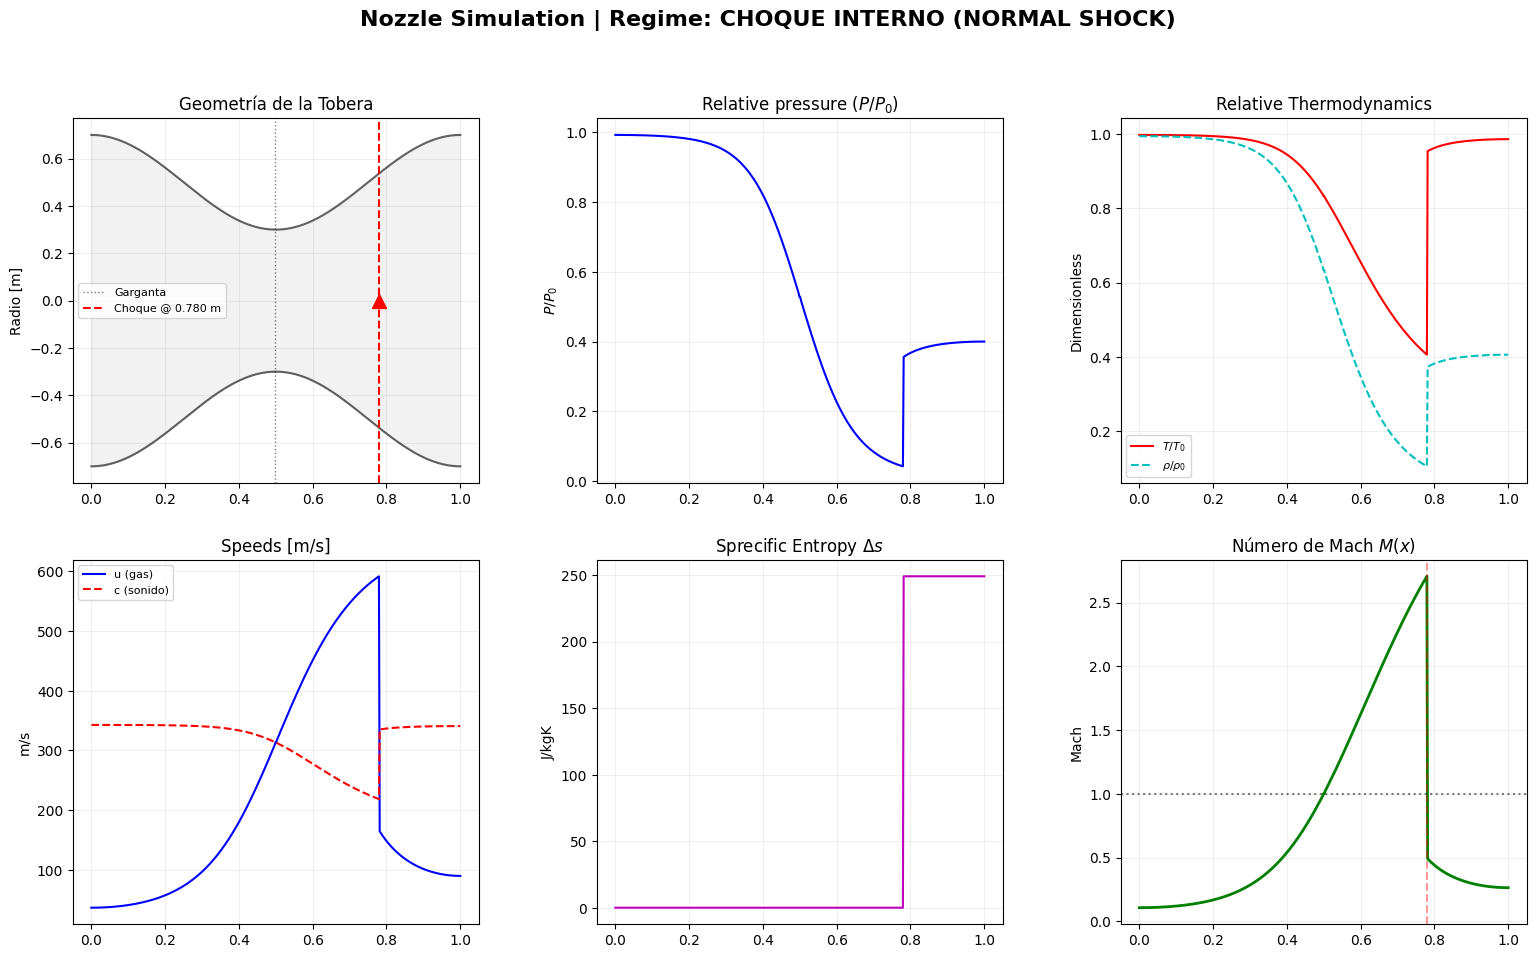


  INFORME TÉCNICO: RÉGIMEN CHOQUE INTERNO (NORMAL SHOCK)

1. CONDICIONES DE CONTORNO Y REMANSO:
   P0: 5.0000e+00 bar | T0: 2.9300e+02 K
   Pa: 2.0000e+00 bar | Referencia: Tobera Fija (Empuje Estático)

2. ESTADO CRÍTICO EN GARGANTA (TEÓRICO):
   P*: 2.6414e+00 bar | T*: 2.4417e+02 K
   mdot_max: 4.3704e+02 kg/s

   LIMITES DE PRESIÓN PARA DISEÑO:
   Ps_sub: 4.9601e+00 bar | Ps_sup: 9.1992e-02 bar

3. RESULTADOS EN PLANO DE SALIDA (SECCIÓN E):
   Mach_e:  2.6391e-01 | Presión_e: 2.0000e+00 bar
   Temp_e:  2.8897e+02 K   | Densidad_e: 2.4111e+00 kg/m3
   Veloc_e: 8.9934e+01 m/s | Caudal m:    3.3380e+02 kg/s
   EMPUJE ESTÁTICO: 3.0020e+04 N
   Salto Entropía Ds: 2.4912e+02 J/kgK

4. ANÁLISIS DE PÉRDIDAS POR CHOQUE:
   Posición xc:      7.8038e-01 m
   Pérdida P0 Total: 6.0000e+01 %

----------------------------------------------------------------------
¿ESTADO ESTRANGULADO?: NO (Subcrítico)
Razón: mdot_real (3.3380e+02) vs mdot_max (4.3704e+02)
----------------------------------------

In [24]:
def radio(x): return r0 + R_amp * np.cos(2 * np.pi * x / L)
def area(x): return np.pi * (radio(x)**2)

x_vec = np.linspace(0, L, 500)
A_vec = area(x_vec)
motor=NozzleFlow( pa, p0   , T0, gamma, R_g, x_vec, A_vec)
# --- TEST DE SALIDA ---
if flg.verbose:
    print(f"DEBUG: Radio en garganta (teórico): {r0 - R_amp:.2f} m")
    print(f"DEBUG: Radio en garganta (calculado): {np.sqrt(motor.At/np.pi):.2f} m")

ps_sub=motor.ps_sub
ps_sup=motor.ps_sup
pstar=motor.p_star

if pa >= motor.p0:
    print(f"ERROR CONCEPTUAL: Pa ({pa}) >= P0 ({motor.p0}).")
    print("No hay gradiente de presión para flujo hacia la salida. Abortando...")
    # Aquí podrías retornar o levantar una excepción
else:
    tol = 1e-5

    # 1. RÉGIMEN VENTURI (Subsónico puro o crítico en garganta)
    if pa >= motor.ps_sub - tol:
        if pa > motor.ps_sub + tol:
            reg_name = "VENTURI (SUBSÓNICO)"
        else:
            reg_name = "VENTURI CRÍTICO (ESTRANGULADO)"

        # Ambos usan el solver subsónico
        results = motor.subsonic_solver(pa, reg_name)

    # 2. RÉGIMEN DE CHOQUE INTERNO
    elif motor.ps_shock <= pa < motor.ps_sub - tol:
        reg_name = "CHOQUE INTERNO (NORMAL SHOCK)"
        # Aquí brentq SIEMPRE encontrará raíz porque estamos en su dominio físico
        results = motor.shocked_solver(pa, reg_name)

    # 3. RÉGIMEN SUPERSÓNICO (Con ajuste externo)
    else: # pa < motor.ps_shock
        if abs(pa - motor.ps_sup) <= tol:
            reg_name = "DISEÑO SUPERSÓNICO (ADAPTADA)"
        elif pa > motor.ps_sup:
            reg_name = "FLUJO SOBRE-EXPANDIDO (EXTERNO)"
        else:
            reg_name = "FLUJO SUB-EXPANDIDO (EXTERNO)"

        # En todos estos casos, el flujo interno es idéntico al de diseño
        results = motor.supersonic_solver(pa, reg_name)



    if flg.show_plots:
        plot_nozzle_results(x_vec, results, reg_name, motor)
        limpiar_consola()
        show_extended_report(results)